In [ ]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from HierarchBayesParcel.evaluation import calc_test_error
import HierarchBayesParcel.arrangements as ar
import nitools as nt
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations

In [6]:
atlas,_= am.get_atlas(atlas_str='SUIT3')
dist = compute_dist(atlas.world.T, resolution=1)


In [13]:
# load model pkl
with open('Y:/data/Cerebellum/Language/ProbabilisticParcellations/language-localizer_mdtb-s1_fusion_k4_SUIT3.pkl', 'rb') as f:
    model = pickle.load(f)

In [14]:
ar_model_logpi = model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

In [15]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

In [16]:
# mdtb vs based on HBP
fname = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/mdtb-s1_mdtb-s2_fusion_k4_SUIT3'
with open(fname + '.pkl', 'rb') as file:
        full_model = pickle.load(file)

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

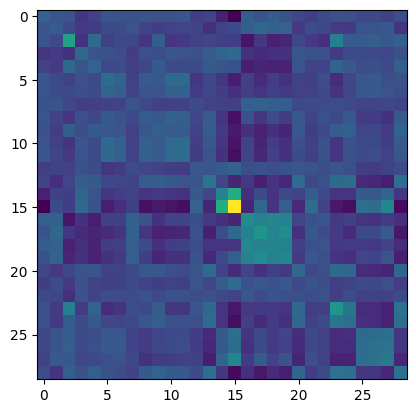

In [17]:
plt.imshow(GL_mdtb)

In [19]:
def HBP_u(train_data,cond_vec,part_vec):
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation
    kappa = M_1.emissions[0].kappa

    return U_data,kappa

In [20]:
def projection_U(Vs,Y):
    U = Vs.T @ Y
    return U


In [22]:
def evaluate_cos(D, ytrain,info, Vs, ytest_all,ytest_run, vtest,M_test):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_HBP_dict = {}
    kappa_dict = {}

    ytest_all = pt.tensor(ytest_all,dtype=pt.float32)
    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)

        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


        y_subset = ytrain[:, task_subset_indices, :]
        y_subset = y_subset - np.mean(y_subset, axis=0)
        y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


        # leverage repeats for HBP
        HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=3)
        U_hat_HBP ,kappa = HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)
        U_hat_HBP = [U_hat_HBP]
        kappa = kappa.item()     
        
        # Compute cos_HBP
        cos_HBP = calc_test_error(M=M_test, tdata=ytest_run, U_hats=U_hat_HBP, fit_emission='use_Uhats').mean()
        
        # Store the result in the dictionary
        cos_HBP_dict[comb_tuple] = cos_HBP
        kappa_dict[comb_tuple] = kappa
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_HBP'] = D['combination_tuple'].map(cos_HBP_dict)
    D['kappa'] = D['combination_tuple'].map(kappa_dict)
    
    return D

In [23]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s2_run,info_mdtb_2_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondRun')
data_mdtb_s2_run[np.isnan(data_mdtb_s2_run)] = 0

data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0



In [24]:
cond_vec_test = np.tile(np.arange(1, 32 + 1), 16)
part_vec_test = np.repeat(np.arange(1, 16 + 1), 32)
data_test = data_mdtb_s2_run


x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


Likelihood decreased - terminating on iteration 14


In [98]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',offs = offsets,n_iter=100,n_tasks=8,seed=3)
D_mdtb = evaluate_cos(D_mdtb, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb, data_mdtb_s2_all,data_mdtb_s2_run, VL_mdtb_2,M_2)


building0
Processing combination: 0
Likelihood decreased - terminating on iteration 51
Subject:0:0.1734s
Subject:1:0.0401s
Subject:2:0.0390s
Subject:3:0.0371s
Subject:4:0.0366s
Subject:5:0.0373s
Subject:6:0.0378s
Subject:7:0.0374s
Subject:8:0.0371s
Subject:9:0.0372s
Subject:10:0.0372s
Subject:11:0.0364s
Subject:12:0.0391s
Subject:13:0.0395s
Subject:14:0.0381s
Subject:15:0.0382s
Subject:16:0.0371s
Subject:17:0.0379s
Subject:18:0.0370s
Subject:19:0.0381s
Subject:20:0.0375s
Subject:21:0.0373s
Subject:22:0.0366s
Subject:23:0.0372s
Processing combination: 1
Subject:0:0.0593s
Subject:1:0.0373s
Subject:2:0.0358s
Subject:3:0.0373s
Subject:4:0.0350s
Subject:5:0.0366s
Subject:6:0.0379s
Subject:7:0.0346s
Subject:8:0.0376s
Subject:9:0.0361s
Subject:10:0.0352s
Subject:11:0.0344s
Subject:12:0.0382s
Subject:13:0.0360s
Subject:14:0.0365s
Subject:15:0.0364s
Subject:16:0.0359s
Subject:17:0.0355s
Subject:18:0.0370s
Subject:19:0.0365s
Subject:20:0.0368s
Subject:21:0.0343s
Subject:22:0.0346s
Subject:23:0.0

In [56]:
# save the dataframe in the current directory
# D_mdtb.to_csv('D_mdtb_comp.csv.gz', index=False,compression='gzip')

# load the dataframe
# D_mdtb = pd.read_csv('D_mdtb.csv')

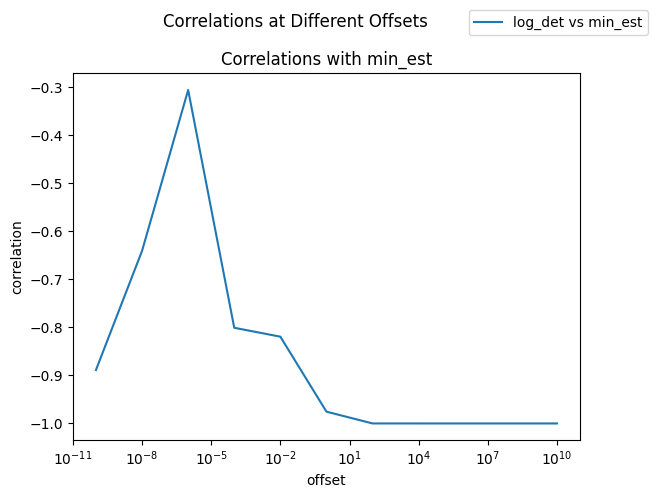

In [83]:
plot_correlations(D_mdtb, x_vars=['log_det'], y_vars=['min_est'])

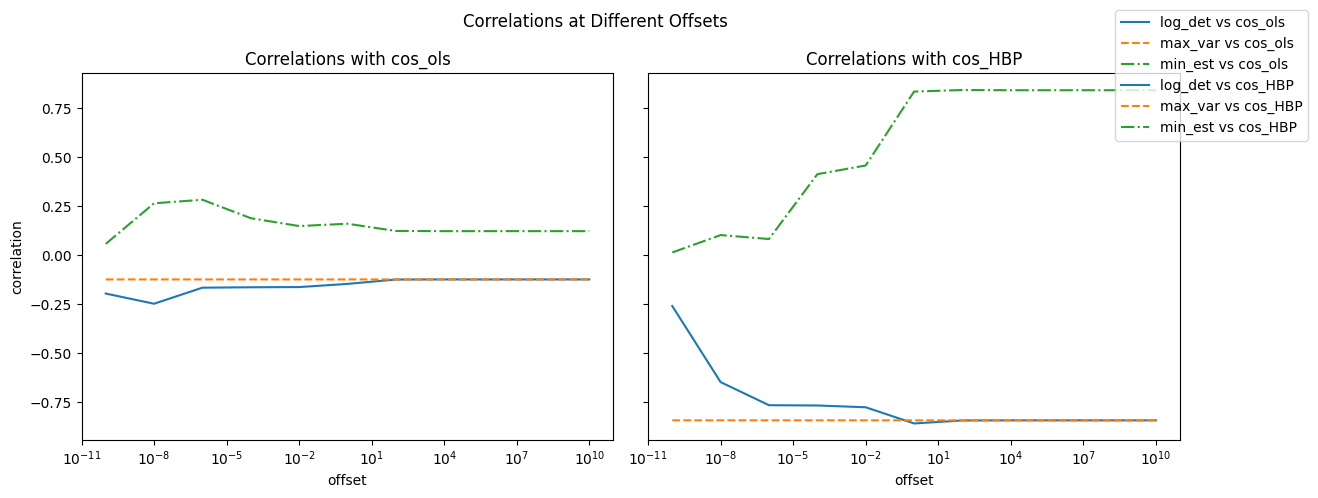

In [85]:
plot_correlations(D_mdtb, x_vars=['log_det','max_var','min_est'], y_vars=['cos_ols','cos_HBP'], show_p_values=False)

In [86]:
# chhoose offset 1.000000e-10
D_mdtb_best = D_mdtb[D_mdtb['offset'] ==1e-6]
# print correlation between max_var and cos_HBP
print(pearsonr(D_mdtb_best['max_var'], D_mdtb_best['cos_HBP']))
print(pearsonr(D_mdtb_best['log_det'], D_mdtb_best['cos_HBP']))
print(pearsonr(D_mdtb_best['kappa'], D_mdtb_best['cos_HBP']))
print(pearsonr(D_mdtb_best['kappa'], D_mdtb_best['max_var']))
print(pearsonr(D_mdtb_best['kappa'], D_mdtb_best['log_det']))
print(pearsonr(D_mdtb_best['kappa'], D_mdtb_best['min_est']))

PearsonRResult(statistic=-0.8415178681752951, pvalue=1.9689391627567087e-14)
PearsonRResult(statistic=-0.7643017093703012, pvalue=1.0570852363539722e-10)
PearsonRResult(statistic=nan, pvalue=nan)
PearsonRResult(statistic=nan, pvalue=nan)
PearsonRResult(statistic=nan, pvalue=nan)
PearsonRResult(statistic=nan, pvalue=nan)
